# EDA — Tren de Alta Velocidad (CulturaTrip)

Este notebook presenta el análisis exploratorio de datos (EDA) del dataset limpio **tren_alta_velocidad_clean.csv**.
Se abordan cuatro ejes principales:

1. **Ruta con mayor número de observaciones** (frecuencia por origen–destino).
2. **Empresas operadoras por ruta** (distribución porcentual).
3. **Distribución de precios** por ruta y empresa (boxplot horizontal).
4. **Tendencias temporales** (variación de precios por mes).

> Nota: Se utiliza una versión “experimental” del dataset con variables principales como `origen`, `destino`, `empresa`, `mes` y `precio`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import math
import matplotlib.ticker as ticker

df_altavelocidad = pd.read_csv("../../data/Experimental/tren_alta_velocidad_clean.csv",
                      encoding="utf-8-sig",
                      dtype=str,
                      keep_default_na=False,
                      na_filter=False
                      )

In [2]:
from pathlib import Path
import os
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 1) Preparación de variables

Para estandarizar el análisis:
- `mes` se convierte a tipo datetime.
- Se crea `destino_clean` (si el destino viene en formato "alicante/alacant", se usa la primera parte).
- Se crea `ruta` concatenando `origen` y `destino_clean` para analizar por origen–destino.
- `precio` se transforma a numérico para evitar errores por strings.

In [4]:
df = df_altavelocidad.copy()

# mes (ej: "2024-01") -> datetime
df["mes"] = pd.to_datetime(df["mes"], errors="coerce")

# destino limpio: "alicante/alacant" -> "alicante"
df["destino_clean"] = df["destino"].astype(str).str.split("/").str[0].str.strip()

# origen limpio
df["origen_clean"] = df["origen"].astype(str).str.strip()

# ruta
df["ruta"] = df["origen_clean"] + " - " + df["destino_clean"]

# precio numérico
df["precio"] = pd.to_numeric(df["precio"], errors="coerce")

print("Nulos por columna:")
display(df.isna().sum())

display(df[["mes","empresa","origen","destino","destino_clean","ruta","precio"]].head())

Nulos por columna:


mes                 0
empresa             0
tipo_de_servicio    0
tipo_de_producto    0
origen              0
destino             0
precio              0
destino_clean       0
origen_clean        0
ruta                0
dtype: int64

,mes,empresa,origen,destino,destino_clean,ruta,precio
0,2022-11-01,iryo,madrid,barcelona,barcelona,madrid - barcelona,45.73
1,2022-11-01,ouigo,madrid,barcelona,barcelona,madrid - barcelona,40.85
2,2022-11-01,ouigo,madrid,valencia/valencia,valencia,madrid - valencia,25.08
3,2022-11-01,renfe-ave,madrid,alicante/alacant,alicante,madrid - alicante,48.73
4,2022-11-01,renfe-ave,madrid,barcelona,barcelona,madrid - barcelona,78.78


In [5]:
print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (609, 10)


,mes,empresa,tipo_de_servicio,tipo_de_producto,origen,destino,precio,destino_clean,origen_clean,ruta
0,2022-11-01,iryo,comercial,ld av,madrid,barcelona,45.73,barcelona,madrid,madrid - barcelona
1,2022-11-01,ouigo,comercial,ld av,madrid,barcelona,40.85,barcelona,madrid,madrid - barcelona
2,2022-11-01,ouigo,comercial,ld av,madrid,valencia/valencia,25.08,valencia,madrid,madrid - valencia
3,2022-11-01,renfe-ave,comercial,ld av,madrid,alicante/alacant,48.73,alicante,madrid,madrid - alicante
4,2022-11-01,renfe-ave,comercial,ld av,madrid,barcelona,78.78,barcelona,madrid,madrid - barcelona


mes                 datetime64[ns]
empresa                     object
tipo_de_servicio            object
tipo_de_producto            object
origen                      object
destino                     object
precio                     float64
destino_clean               object
origen_clean                object
ruta                        object
dtype: object

## 2) Ruta con mayor número de observaciones

Se calcula el número de registros por `ruta` (origen–destino) para identificar:
- rutas más representadas en el dataset,
- posibles sesgos de muestreo (rutas con muchísima más data que otras).

,ruta,n_obs
1,madrid - barcelona,140
4,madrid - valencia,139
0,madrid - alicante,124
2,madrid - malaga,103
3,madrid - sevilla,103


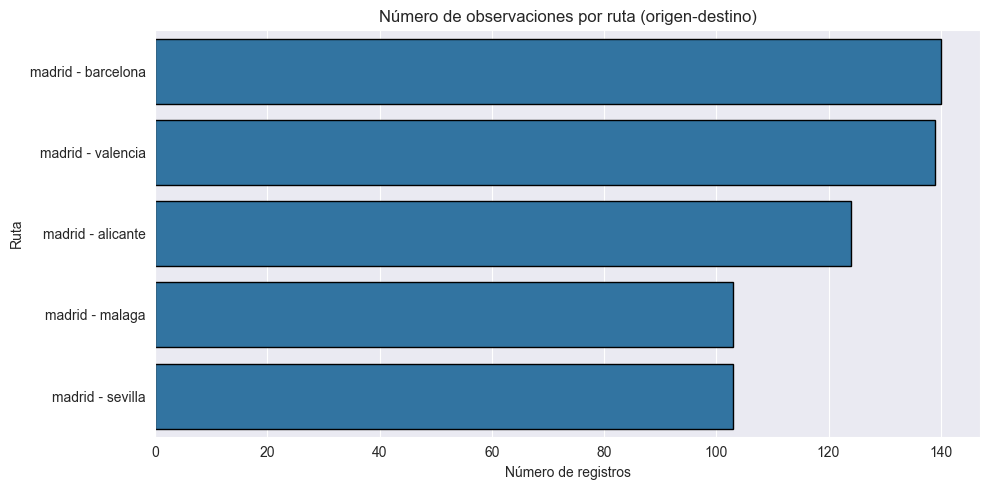

In [6]:
ruta_counts = (
    df.groupby("ruta", dropna=False)
      .size()
      .reset_index(name="n_obs")
      .sort_values("n_obs", ascending=False)
)

display(ruta_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=ruta_counts, x="n_obs", y="ruta", edgecolor="black")
plt.title("Número de observaciones por ruta (origen-destino)")
plt.xlabel("Número de registros")
plt.ylabel("Ruta")
plt.tight_layout()
  # Guardar en assets

plt.savefig(ASSETS_DIR / "Número de observaciones por ruta (origen-destino)", dpi=300)
plt.show()
plt.close()

## 3) Empresas operadoras por ruta (distribución porcentual)

Se analiza la participación de cada `empresa` dentro de cada `ruta`.
Esto permite ver:
- si una ruta está dominada por un solo operador,
- si hay competencia real en esa ruta,
- qué rutas tienen distribución más equilibrada.

,ruta,empresa,n,pct
2,madrid - alicante,renfe-ave,35,28.225806
3,madrid - alicante,renfe-avlo,31,25.000000
1,madrid - alicante,ouigo,30,24.193548
0,madrid - alicante,iryo,28,22.580645
4,madrid - barcelona,iryo,35,25.000000
5,madrid - barcelona,ouigo,35,25.000000
6,madrid - barcelona,renfe-ave,35,25.000000
7,madrid - barcelona,renfe-avlo,35,25.000000
10,madrid - malaga,renfe-ave,35,33.980583
8,madrid - malaga,iryo,31,30.097087


empresa,iryo,ouigo,renfe-ave,renfe-avlo
ruta,,,,
madrid - alicante,22.580645,24.193548,28.225806,25.000000
madrid - barcelona,25.000000,25.000000,25.000000,25.000000
madrid - malaga,30.097087,8.737864,33.980583,27.184466
madrid - sevilla,30.097087,8.737864,33.980583,27.184466
madrid - valencia,24.460432,25.179856,25.179856,25.179856


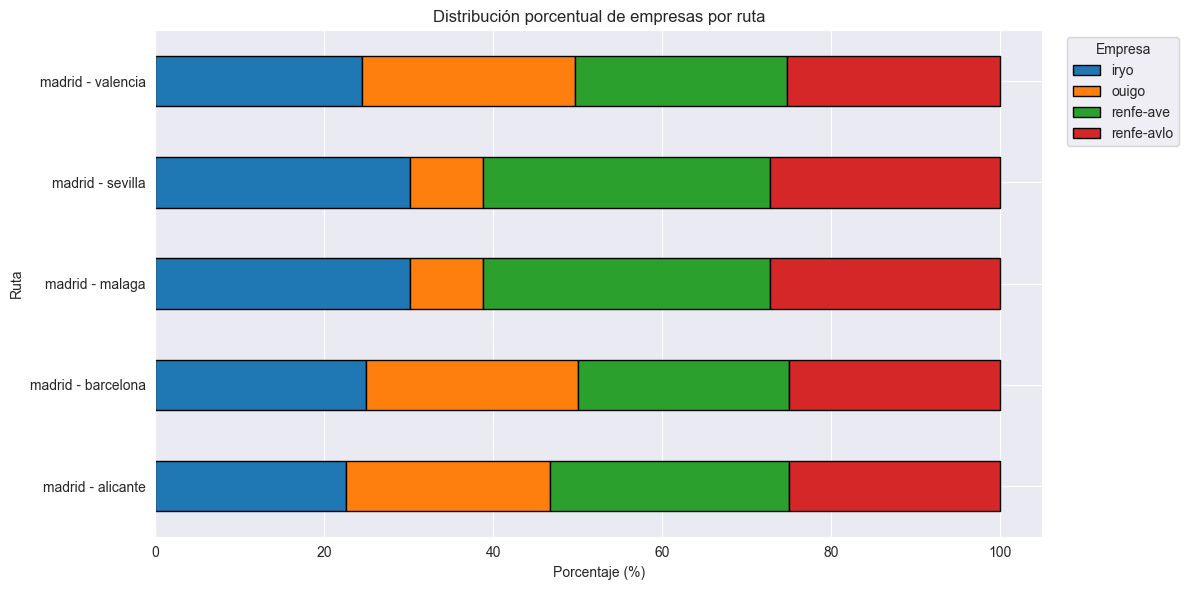

In [7]:
ruta_empresa_counts = (
    df.groupby(["ruta", "empresa"], dropna=False)
      .size()
      .reset_index(name="n")
)

totales_por_ruta = ruta_empresa_counts.groupby("ruta")["n"].transform("sum")
ruta_empresa_counts["pct"] = (ruta_empresa_counts["n"] / totales_por_ruta) * 100

display(ruta_empresa_counts.sort_values(["ruta","pct"], ascending=[True, False]))

pivot_pct = ruta_empresa_counts.pivot(index="ruta", columns="empresa", values="pct").fillna(0)
display(pivot_pct)

ax = pivot_pct.plot(kind="barh", stacked=True, figsize=(12, 6), edgecolor="black")
plt.title("Distribución porcentual de empresas por ruta")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Ruta")
plt.legend(title="Empresa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
 # Guardar en assets

plt.savefig(ASSETS_DIR / "Distribución porcentual de empresas por ruta", dpi=300)
plt.show()
plt.close()

## 4) Distribución de precios por ruta y empresa (Boxplot)

Se utiliza un boxplot horizontal para observar:
- mediana del precio por operador,
- dispersión y variabilidad,
- presencia de outliers,
- rutas con mayor rango de precios (posibles estrategias de pricing diferentes).

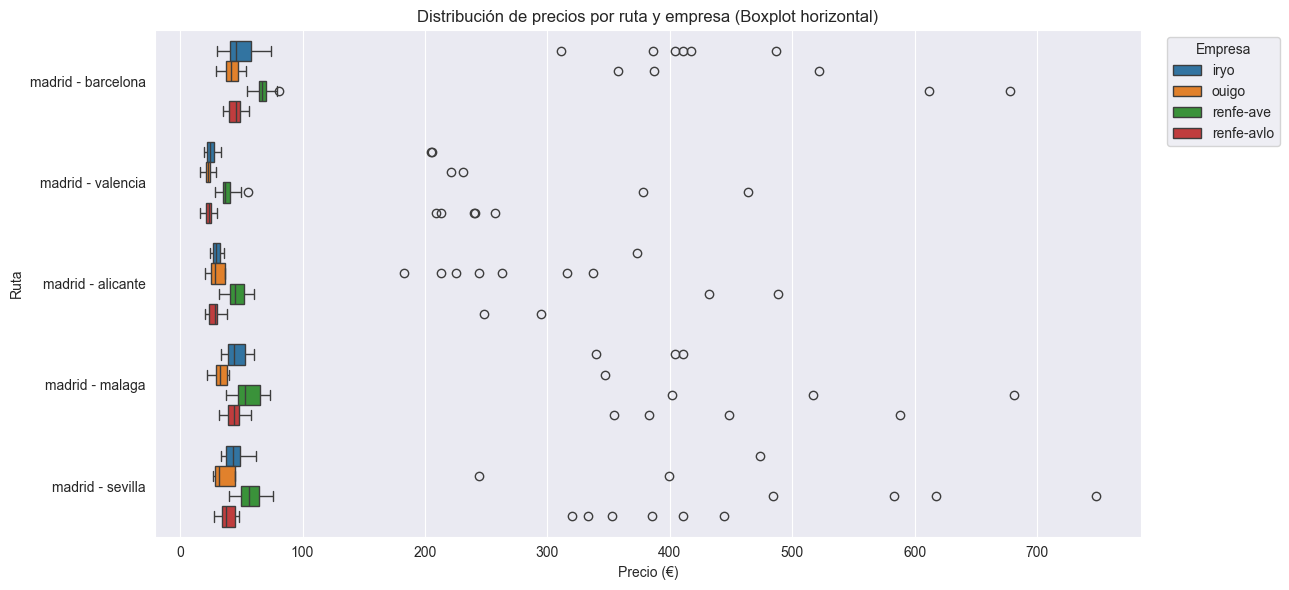

,ruta,empresa,n,media,mediana,min,max,std
0,madrid - alicante,iryo,28,41.885357,29.225,24.41,373.00,64.972294
3,madrid - alicante,renfe-avlo,31,42.923548,28.530,20.24,295.00,61.461151
2,madrid - alicante,renfe-ave,35,69.045429,44.850,32.06,488.00,98.130572
1,madrid - alicante,ouigo,30,79.898000,28.350,20.19,337.00,101.211533
7,madrid - barcelona,renfe-avlo,35,44.876857,45.630,34.94,56.43,5.625435
5,madrid - barcelona,ouigo,35,73.896857,41.750,29.71,522.00,110.469875
6,madrid - barcelona,renfe-ave,35,99.823714,67.070,54.94,678.00,136.524058
4,madrid - barcelona,iryo,35,107.368286,45.730,30.52,487.00,138.250345
9,madrid - malaga,ouigo,9,66.505556,32.220,21.96,347.00,105.324174
8,madrid - malaga,iryo,31,77.454839,43.780,33.67,411.00,103.082165


In [8]:
plt.figure(figsize=(13, 6))
sns.boxplot(
    data=df.dropna(subset=["precio", "ruta", "empresa"]),
    y="ruta",
    x="precio",
    hue="empresa",
    orient="h"
)
plt.title("Distribución de precios por ruta y empresa (Boxplot horizontal)")
plt.xlabel("Precio (€)")
plt.ylabel("Ruta")
plt.legend(title="Empresa", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Distribución de precios por ruta y empresa (Boxplot horizontal)", dpi=300)
plt.show()
plt.close()

resumen_precios = (
    df.groupby(["ruta","empresa"], dropna=False)["precio"]
      .agg(n="count", media="mean", mediana="median", min="min", max="max", std="std")
      .reset_index()
      .sort_values(["ruta","media"])
)

display(resumen_precios)

## 5) Tendencias temporales (precios por mes)

Se analiza la evolución del **precio promedio** por:
- `ruta`,
- `empresa`,
- `mes`.

Esto permite identificar estacionalidad:
- meses con precios más altos/bajos,
- cambios de estrategia por operador,
- rutas sensibles a temporada.

,ruta,empresa,mes,precio_promedio
0,madrid - alicante,iryo,2023-06-01,29.64
1,madrid - alicante,iryo,2023-07-01,34.65
2,madrid - alicante,iryo,2023-08-01,28.99
3,madrid - alicante,iryo,2023-09-01,25.42
4,madrid - alicante,iryo,2023-10-01,33.04


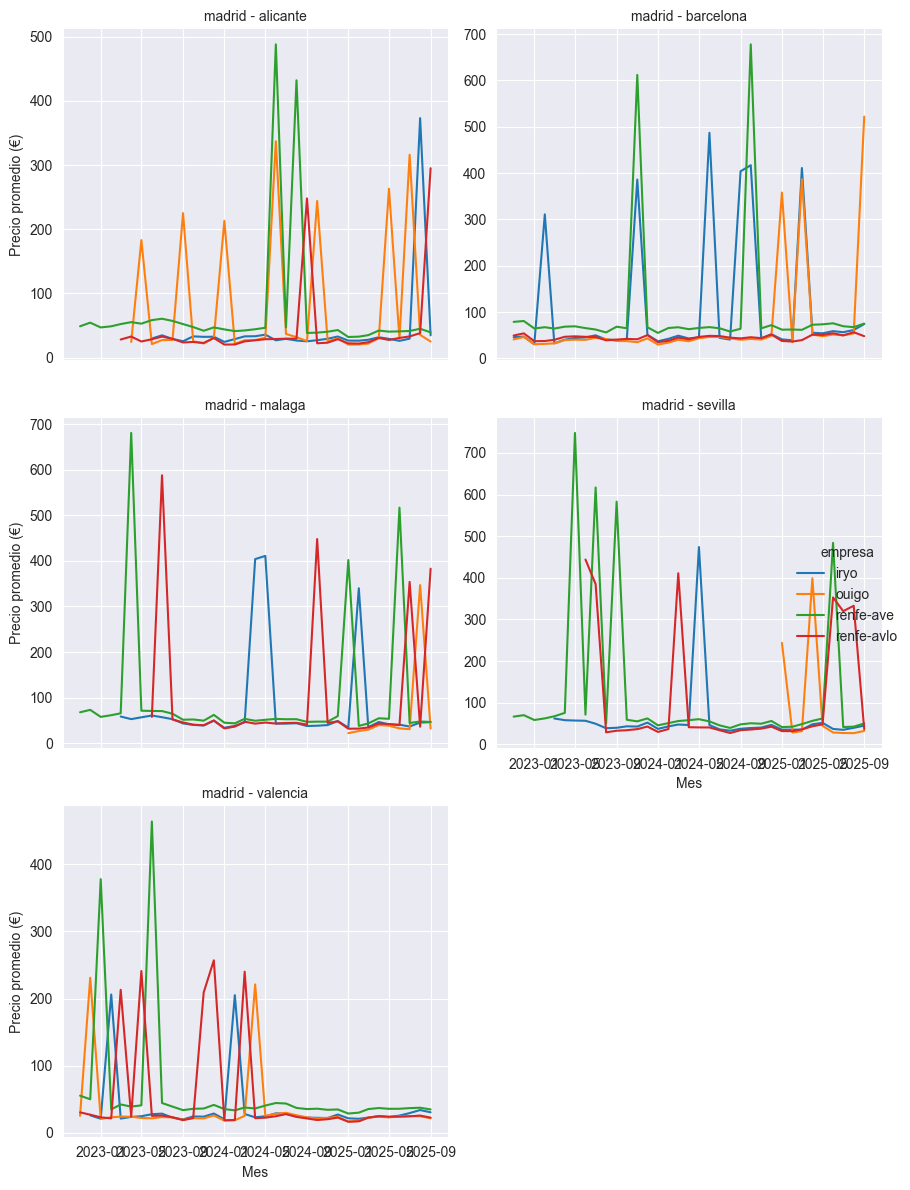

In [9]:
ts = (
    df.dropna(subset=["mes","precio"])
      .groupby(["ruta", "empresa", "mes"], as_index=False)["precio"]
      .mean()
      .rename(columns={"precio":"precio_promedio"})
)

display(ts.head())

g = sns.relplot(
    data=ts,
    x="mes",
    y="precio_promedio",
    hue="empresa",
    col="ruta",
    col_wrap=2,
    kind="line",
    height=4,
    facet_kws={"sharey": False, "sharex": True}
)
g.set_titles("{col_name}")
g.set_axis_labels("Mes", "Precio promedio (€)")
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Serie temporal por ruta y empresa", dpi=300)
plt.show()
plt.close()

### 5.1) Meses más baratos y más caros (global)

Se agrega el dataset por mes (global) para identificar:
- Top meses más baratos,
- Top meses más caros,
como aproximación a estacionalidad general del mercado.

,mes_num,precio_promedio,mes_nombre
0,1,62.588980,Jan
1,2,54.179592,Feb
2,3,67.848269,Mar
3,4,70.761132,Apr
4,5,81.784151,May
5,6,99.639286,Jun
6,7,82.601429,Jul
7,8,63.249286,Aug
8,9,80.881250,Sep
9,10,82.211389,Oct


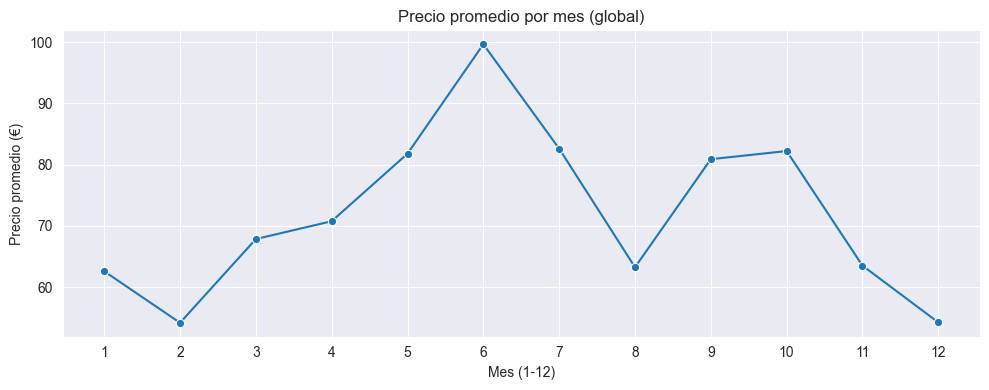

Meses más baratos (Top 3):


,mes_num,mes_nombre,precio_promedio
1,2,Feb,54.179592
11,12,Dec,54.246596
0,1,Jan,62.588980


Meses más caros (Top 3):


,mes_num,mes_nombre,precio_promedio
5,6,Jun,99.639286
6,7,Jul,82.601429
9,10,Oct,82.211389


In [10]:
df["mes_num"] = df["mes"].dt.month
df["mes_nombre"] = df["mes"].dt.strftime("%b")

global_mes = (
    df.dropna(subset=["mes","precio"])
      .groupby("mes_num", as_index=False)["precio"]
      .mean()
      .rename(columns={"precio":"precio_promedio"})
      .sort_values("mes_num")
)

mes_map = (df.dropna(subset=["mes"])
             .assign(mes_num=df["mes"].dt.month,
                     mes_nombre=df["mes"].dt.strftime("%b"))
             .drop_duplicates(subset=["mes_num"])[["mes_num","mes_nombre"]])

global_mes = global_mes.merge(mes_map, on="mes_num", how="left")
display(global_mes)

plt.figure(figsize=(10, 4))
sns.lineplot(data=global_mes, x="mes_num", y="precio_promedio", marker="o")
plt.title("Precio promedio por mes (global)")
plt.xlabel("Mes (1-12)")
plt.ylabel("Precio promedio (€)")
plt.xticks(range(1, 13))
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio promedio por mes (global)", dpi=300)
plt.show()
plt.close()

baratos = global_mes.nsmallest(3, "precio_promedio")[["mes_num","mes_nombre","precio_promedio"]]
caros   = global_mes.nlargest(3, "precio_promedio")[["mes_num","mes_nombre","precio_promedio"]]

print("Meses más baratos (Top 3):")
display(baratos)

print("Meses más caros (Top 3):")
display(caros)

## 6) (Extra recomendado) Ranking de empresas por precio promedio

Se calcula el precio promedio y mediano por empresa para comparar operadores en general.
También se muestra el promedio por ruta–empresa para ver diferencias dentro de rutas específicas.

,empresa,n,precio_promedio,mediana
1,ouigo,118,64.820508,30.45
0,iryo,159,64.972138,38.96
3,renfe-avlo,157,67.376242,36.79
2,renfe-ave,175,88.483314,52.18


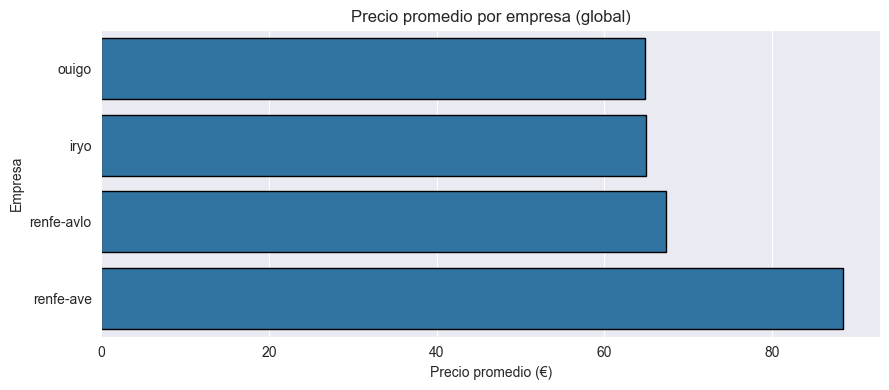

,ruta,empresa,precio_promedio
0,madrid - alicante,iryo,41.885357
3,madrid - alicante,renfe-avlo,42.923548
2,madrid - alicante,renfe-ave,69.045429
1,madrid - alicante,ouigo,79.898000
7,madrid - barcelona,renfe-avlo,44.876857
5,madrid - barcelona,ouigo,73.896857
6,madrid - barcelona,renfe-ave,99.823714
4,madrid - barcelona,iryo,107.368286
9,madrid - malaga,ouigo,66.505556
8,madrid - malaga,iryo,77.454839


In [11]:
empresa_rank = (
    df.groupby("empresa")["precio"]
      .agg(n="count", precio_promedio="mean", mediana="median")
      .reset_index()
      .sort_values("precio_promedio")
)
display(empresa_rank)

plt.figure(figsize=(9, 4))
sns.barplot(data=empresa_rank, x="precio_promedio", y="empresa", edgecolor="black")
plt.title("Precio promedio por empresa (global)")
plt.xlabel("Precio promedio (€)")
plt.ylabel("Empresa")
plt.tight_layout()
plt.tight_layout()
# Guardar en assets

plt.savefig(ASSETS_DIR / "Precio promedio por empresa (global)", dpi=300)
plt.show()
plt.close()


ruta_empresa_rank = (
    df.groupby(["ruta","empresa"])["precio"]
      .mean()
      .reset_index(name="precio_promedio")
      .sort_values(["ruta","precio_promedio"])
)
display(ruta_empresa_rank)

## Cierre

Este EDA permite:
- identificar rutas más representadas en el dataset,
- entender la presencia competitiva por operador en cada ruta,
- comparar distribución de precios (mediana, dispersión, outliers),
- detectar estacionalidad temporal y meses con precios extremos.

Estos hallazgos son la base para:
- feature engineering (mes, temporada, operador, ruta),
- modelos predictivos de precio,
- recomendaciones de compra basadas en mejor época y mejor operador.